In [2]:
import pandas as pd

df = pd.read_parquet('../data/Processed Positions Data.parquet')
df = df.drop(columns=['gameId', 'gameDateTimeEst_player', 'coachId'])

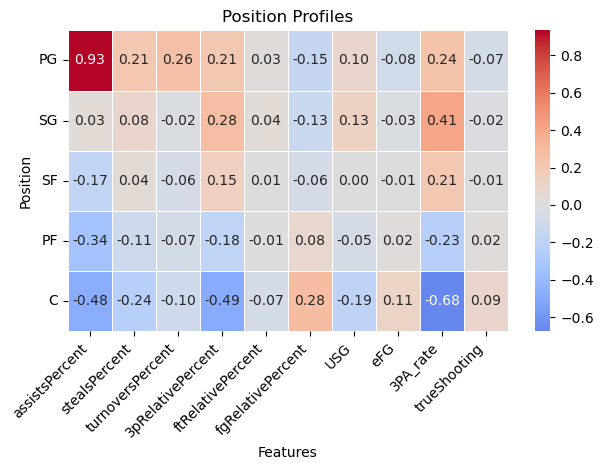

<Figure size 640x480 with 0 Axes>

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
import seaborn as sns

features_heatmap = ['assistsPercent', 'stealsPercent', 'turnoversPercent',
                    '3pRelativePercent', 'ftRelativePercent', 'fgRelativePercent',
                    'USG', 'eFG', '3PA_rate', 'trueShooting']
X = df[features_heatmap]
y = df['Position']

scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=features_heatmap,
                         index=df.index)
position_profile = X.copy()
position_profile['Position'] = y
position_means = position_profile.groupby('Position').mean()
position_means = position_means.reindex(['PG', 'SG', 'SF',
                                         'PF', 'C'])

sns.heatmap(
    position_means,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot=True,
    fmt='.2f'
)

plt.title("Position Profiles")
plt.xlabel("Features")
plt.ylabel("Position")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

plt.savefig('../output/Exploratory/Position Profiles.svg')

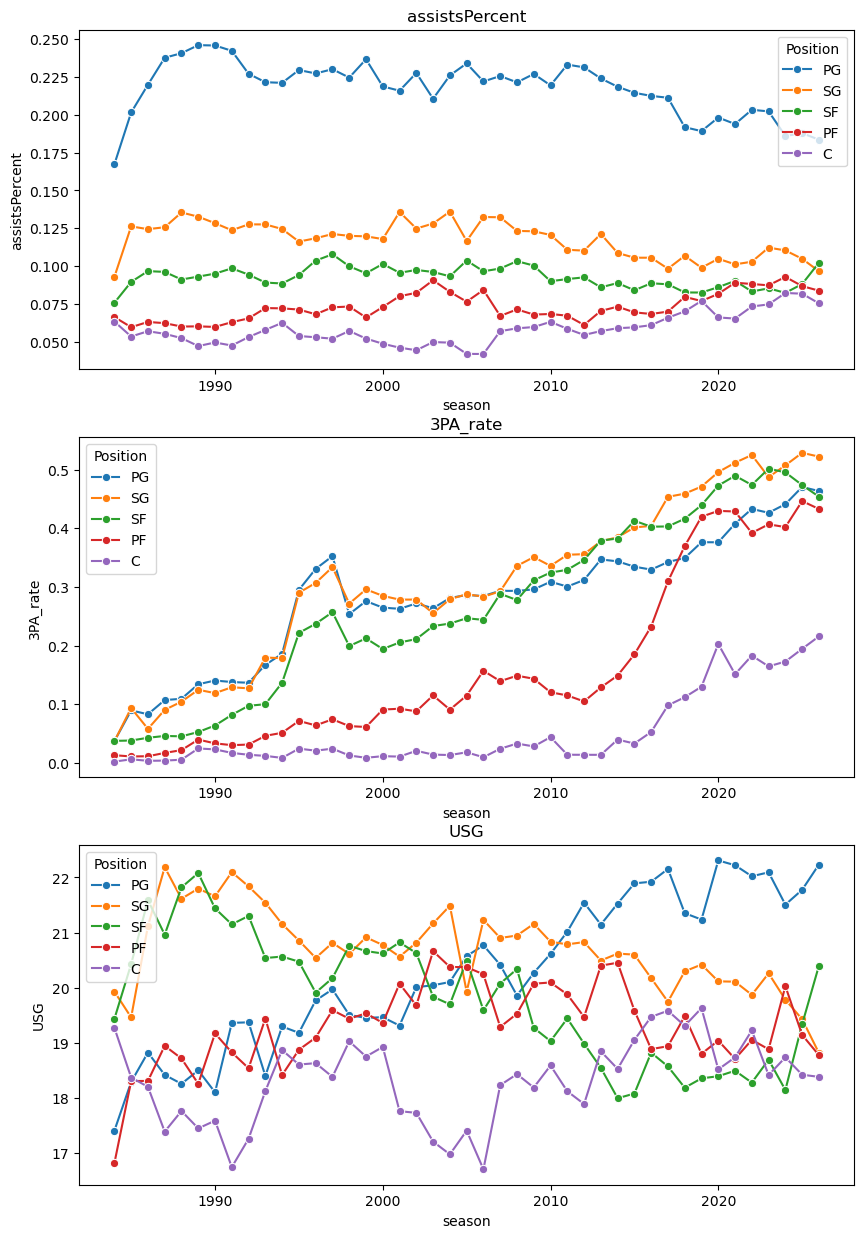

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [4]:
features_to_examine = ['assistsPercent', '3PA_rate', 'USG']
fig, ax = plt.subplots(figsize=(10, 15), nrows=3, ncols=1)
season_pos = (
    df
    .groupby(["season", "Position"])[features_to_examine]
    .mean()
    .reset_index()
)

order = ["PG", "SG", "SF", "PF", "C"]
season_pos["Position"] = pd.Categorical(season_pos["Position"], categories=order, ordered=True)
season_pos = season_pos.sort_values("Position")
for i, feature_to_examine in enumerate(features_to_examine):
  plt.figure(figsize=(10,5))

  sns.lineplot(
      data=season_pos,
      x="season",
      y=feature_to_examine,
      hue="Position",
      marker="o",
      ax=ax[i]
  )
  ax[i].set_title(f"{feature_to_examine}")
plt.show()

plt.savefig('../output/Exploratory/Position Profiles Over Time.svg')

In [5]:
vc = df['Position'].value_counts()
vc


Position
SG    186412
PF    178455
PG    174439
SF    168619
C     165569
Name: count, dtype: int64

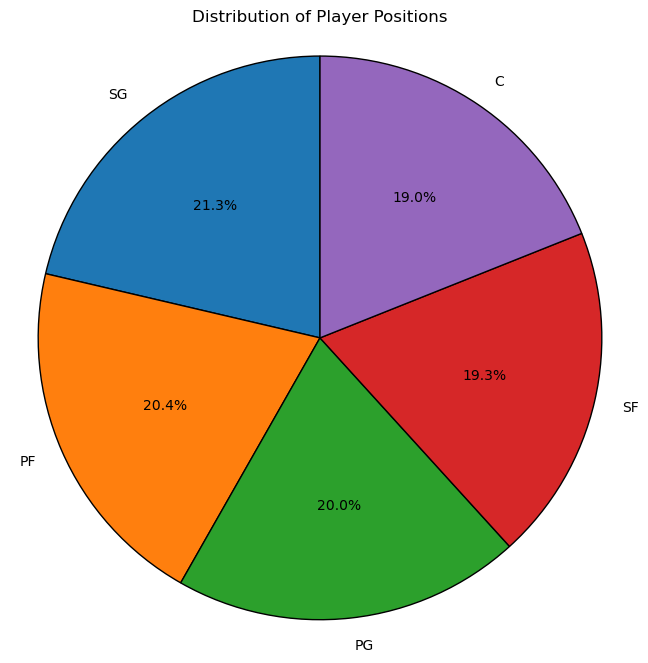

<Figure size 640x480 with 0 Axes>

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.pie(vc, labels=vc.index, autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'black'})
plt.title('Distribution of Player Positions')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

plt.savefig('../output/Exploratory/Player Position Distribution.svg')

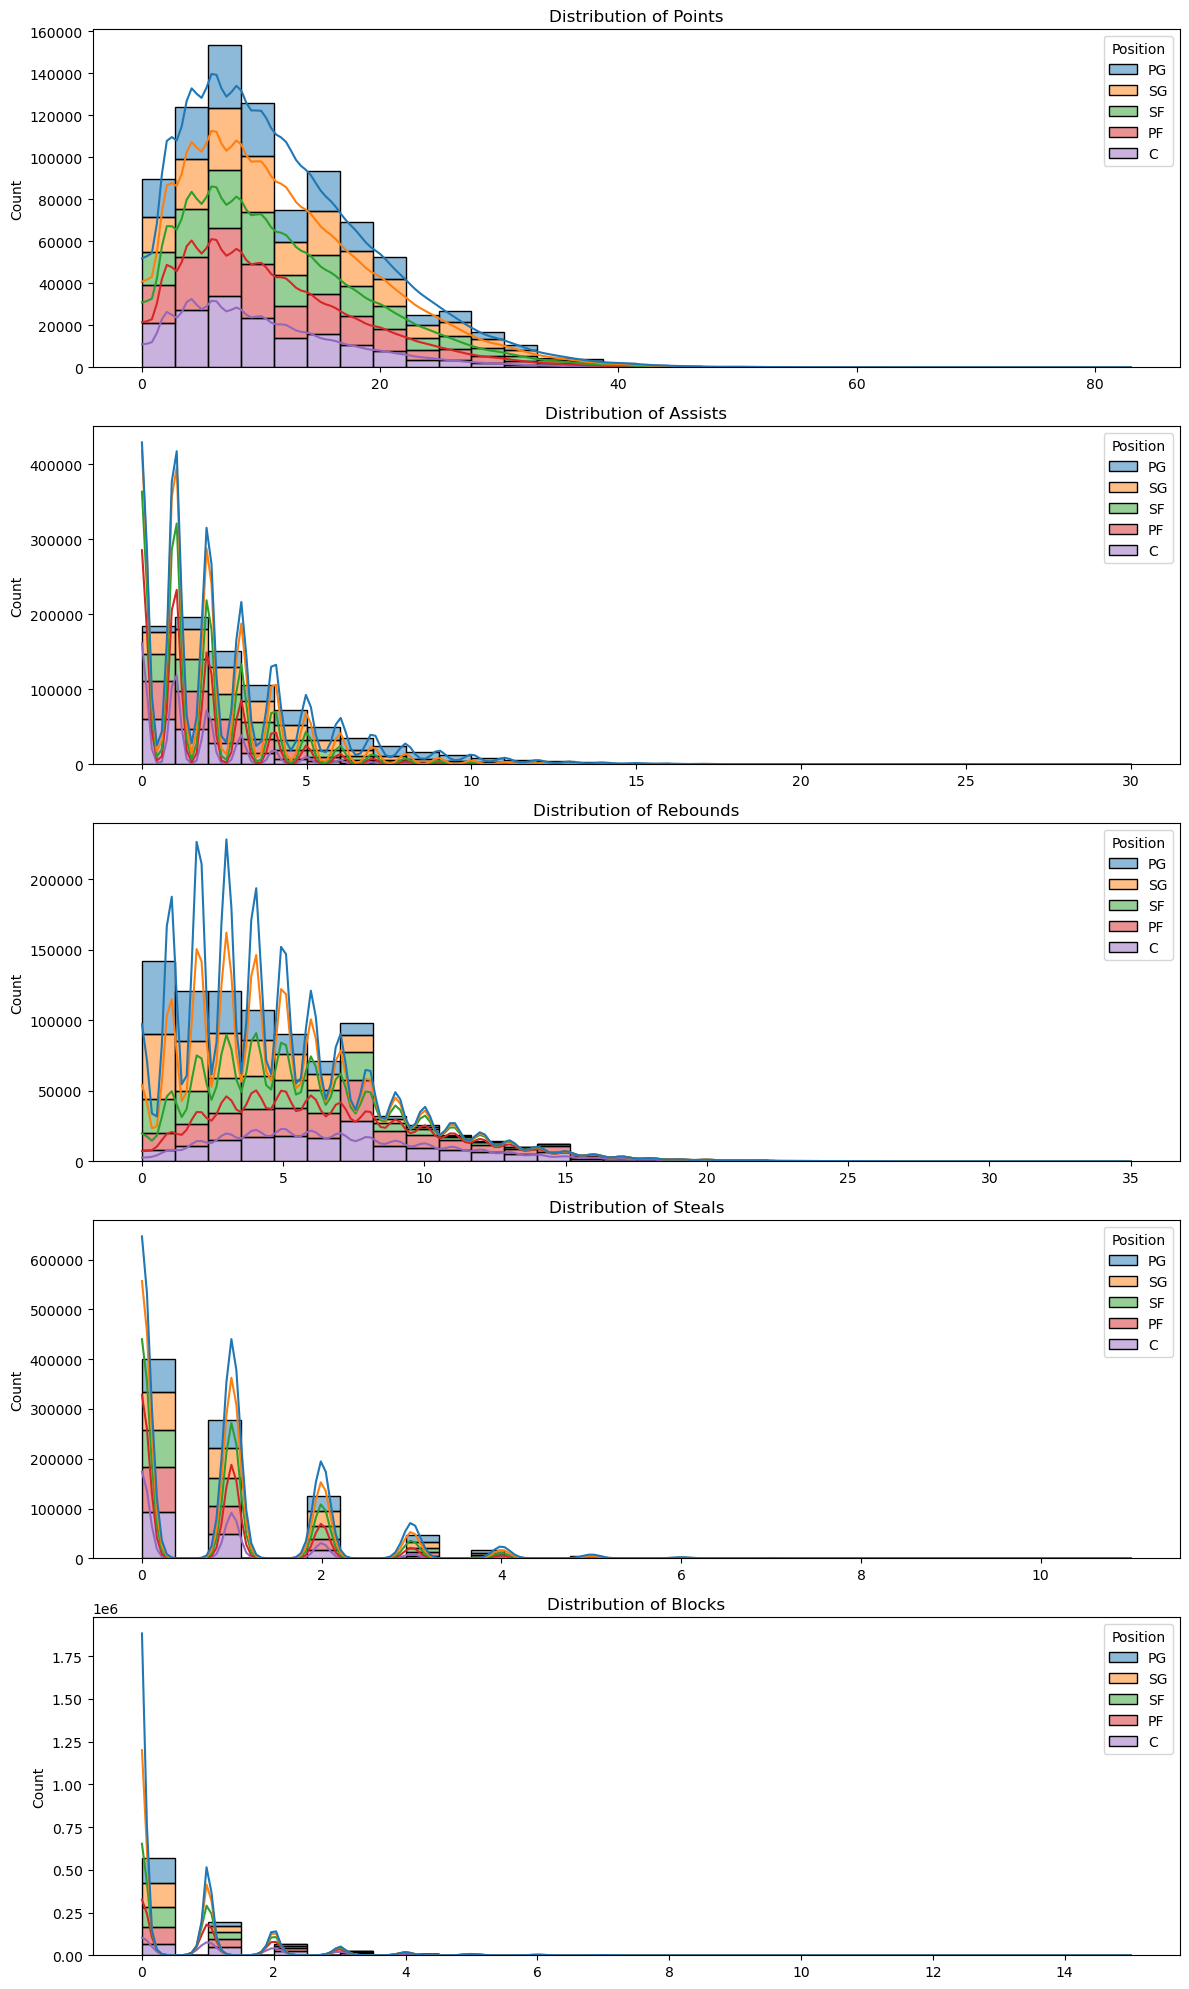

<Figure size 640x480 with 0 Axes>

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the features to plot that are available in the DataFrame
features_to_plot = ['points_player', 'assists_player',
                    'reboundsTotal_player', 'steals_player',
                    'blocks_player']

# Create a figure and a set of subplots
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(12, 20))

position_order = ['PG', 'SG', 'SF', 'PF', 'C']
df['Position'] = pd.Categorical(df['Position'], categories=position_order, ordered=True)

# Loop through the features and plot a histogram for each
for i, feature in enumerate(features_to_plot):
    sns.histplot(data=df, x=feature, bins=30, kde=True, ax=axes[i],
                 hue='Position', multiple='stack', hue_order=position_order)
    axes[i].set_title(f'Distribution of {feature.split('_')[0].capitalize()
      if feature != 'reboundsTotal_player' else 'Rebounds'}')
    axes[i].set_ylabel('Count')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

plt.savefig('../output/Exploratory/Major Stats by Position.svg')

In [8]:
important_features = ['numMinutes_player', 'assists_player', 'blocks_player', 'steals_player',
       'fieldGoalsMade_player', 'threePointersMade_player',
       'threePointersPercentage_player', 'freeThrowsAttempted_player',
       'freeThrowsPercentage_player', 'reboundsDefensive_player',
       'reboundsOffensive_player', 'reboundsTotal_player', 'turnovers_player',
       'plusMinusPoints_player', 'threePointersAttempted_per36',
       'foulsPersonal_per36', 'season', 'foulsPersonalPercent',
       'fgRelativePercent', 'FTA_rate', 'USG']

df = df[important_features + ['Position']]
df.describe()

,numMinutes_player,assists_player,blocks_player,steals_player,fieldGoalsMade_player,threePointersMade_player,threePointersPercentage_player,freeThrowsAttempted_player,freeThrowsPercentage_player,reboundsDefensive_player,...,reboundsTotal_player,turnovers_player,plusMinusPoints_player,threePointersAttempted_per36,foulsPersonal_per36,season,foulsPersonalPercent,fgRelativePercent,FTA_rate,USG
count,873494.000000,873494.000000,873494.000000,873494.000000,873494.000000,873494.000000,873494.000000,873494.000000,873494.000000,873494.000000,...,873494.000000,873494.000000,873494.000000,873494.000000,873494.000000,873494.000000,873492.000000,873494.000000,873494.000000,873494.000000
mean,26.565207,2.605221,0.554347,0.881879,4.368895,0.774179,0.198313,2.807253,0.509718,3.449092,...,4.760493,1.583743,0.207455,0.080315,0.095756,2006.841457,0.108911,-0.004864,0.336332,19.738590
std,9.244600,2.690828,0.968390,1.060337,3.069788,1.234366,0.288642,3.092902,0.418972,2.712233,...,3.572818,1.473769,9.935534,0.091885,0.070287,11.749032,0.068057,0.200238,0.461841,7.347412
min,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,-60.000000,0.000000,0.000000,1984.000000,0.000000,-0.686000,0.000000,1.102607
25%,19.000000,1.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,2.000000,0.000000,-5.000000,0.000000,0.048780,1997.000000,0.055556,-0.118000,0.000000,14.519445
50%,26.090000,2.000000,0.000000,1.000000,4.000000,0.000000,0.000000,2.000000,0.500000,3.000000,...,4.000000,1.000000,0.000000,0.052632,0.083333,2007.000000,0.105263,-0.001000,0.227273,19.344221
75%,34.000000,4.000000,1.000000,1.000000,6.000000,1.000000,0.375000,4.000000,1.000000,5.000000,...,7.000000,2.000000,5.000000,0.136364,0.130435,2017.000000,0.153846,0.108000,0.500000,24.498526
max,69.000000,30.000000,15.000000,11.000000,28.000000,14.000000,1.000000,43.000000,1.000000,26.000000,...,35.000000,14.000000,57.000000,0.923077,0.600000,2026.000000,0.666667,0.756000,17.000000,66.089351


C:\Users\vtapi\AppData\Local\Temp\ipykernel_3084\1445404666.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Position")[important_features]
C:\Users\vtapi\AppData\Local\Temp\ipykernel_3084\1445404666.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Position")[important_features]
C:\Users\vtapi\AppData\Local\Temp\ipykernel_3084\1445404666.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .gr

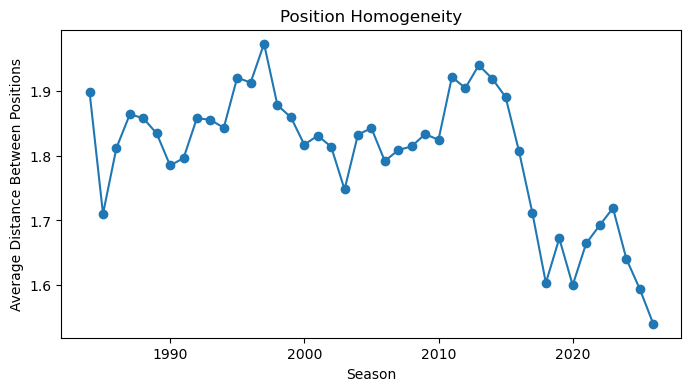

<Figure size 640x480 with 0 Axes>

In [9]:
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# remove season from feature list if present
important_features = [f for f in important_features if f != "season"]

# standardize features globally
df[important_features] = StandardScaler().fit_transform(df[important_features])

def position_gap(season_df):
    # mean feature vector for each position in that season
    grouped = (
        season_df
        .groupby("Position")[important_features]
        .mean()
    )

    # need at least 2 positions to compare
    if len(grouped) < 2:
        return np.nan

    # average pairwise euclidean distance between position centroids
    return pdist(grouped.values, metric="euclidean").mean()

gap_by_season = (
    df
    .groupby("season")
    .apply(position_gap)
    .reset_index(name="position_gap")
)

plt.figure(figsize=(8, 4))
plt.plot(
    gap_by_season["season"],
    gap_by_season["position_gap"],
    marker="o"
)

plt.title("Position Homogeneity")
plt.xlabel("Season")
plt.ylabel("Average Distance Between Positions")
plt.show()

plt.savefig('../output/Exploratory/Position Homogeneity Over Time.svg')